---
title: Detecting cold fronts using day-to-day difference in maximum temperature
authors:
  - pao_corrales
downloads:
  - file: ./cold-fronts.zip
    title: Download this recipe (.zip)
---

Cold fronts are an important feature of weather in extratropical regions and their associated circulation contribute a substantial fraction of the precipitation in these regions ([Konstali el al 2024](10.1029/2024JD041190); [Catto el al 2013](https://doi.org/10.1002/jgrd.50852)). Cold fronts are at times linked to extreme events, such as heavy precipitation ([Catto el al 2013](https://doi.org/10.1002/jgrd.50852)) and severe wildfires in southern Australia ([Reeder el al 2015](https://doi.org/10.1002/2015GL063125)) and other regions. Understanding how cold fronts, and especially strong cold fronts, change in a warming climate is therefore of importance for understanding the changing likelihood of extremes and fire weather.

Here, we take the simplest approach, first introduced by [Reeder el al 2015](https://doi.org/10.1002/2015GL063125). We measure the occurrence of cold fronts using temporal changes in temperature at a fixed location. Specifically, we identify the passage of cold fronts with large day-to-day falls in near-surface daily-maximum temperature. 
This method has been shown to be suitable for the detection of strong cold fronts in southeastern Australia ([Cai el al 2022](https://doi.org/10.1088/1748-9326/ac8e88); [Reeder el al 2015](https://doi.org/10.1002/2015GL063125)), and can successfully identify cold fronts in data with different resolutions, including both station data and reanalyses ([King el al 2024](https://doi.org/10.1002/qj.4841)). [King el al 2024](https://doi.org/10.1002/qj.4841) developed a climatology of cold-front frequency in global climate models from phase 6 of the Coupled Model Intercomparison Project (CMIP6) which produced results comparable to other, more complex, cold-front detection algorithms. While the models tend to overestimate front frequency in polar regions and underestimate the occurrence of large temperature falls over midlatitude land regions compared with ERA5, they accurately represent the patterns of front frequency equatorward of about 60°.


In [5]:
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

Here I use the output from a ACCESS-AM3 global experiment that run from 2007 to 2008 with a resolution of n96e (135 km).

In [2]:
pattern = "data/am3a.pb*.nc"  
files = glob.glob(pattern)

varname = "fld_s03i236_max"  

ds = xr.open_mfdataset(
    files,
    combine="by_coords",  
)

da = ds[varname]

/tmp/ipykernel_1091182/3078843990.py:6: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


We identify falls in near-surface (2 meter) air temperature as a proxy for frontal passages by calculating the change in daily maximum temperature from one day to the next ($\Delta T$). $\Delta T$ is calculated for all grid points and days in the study period. [King el al 2024](https://doi.org/10.1002/qj.4841) defined a passage of a strong cold front as $\Delta T \le -10^{\circ}C$. That is, a cold front passage is identified on day $i$ if the maximum temperature on day $i+1$ is at least 10 deg C lower than that of day $i$. While this value is reasonable for detecting strong falls in temperature over land, it may underestimate the frequency of fronts over the ocean due to the weaker temperature variability. 


In [3]:
da_deltat = da.diff(dim="time")

# Fronts are deltat < -10, count frecuency by year
da_fronts = (da_deltat <= -10).groupby("time.year").sum(dim="time") 
da_fronts

<xarray.DataArray 'fld_s03i236_max' (year: 2, lat: 144, lon: 192)> Size: 442kB
dask.array<stack, shape=(2, 144, 192), dtype=int64, chunksize=(1, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 16B 2007 2008
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    height   float64 8B 1.5
Attributes:
    standard_name:    air_temperature
    long_name:        TEMPERATURE AT 1.5M
    units:            K
    grid_mapping:     latitude_longitude
    um_stash_source:  m01s03i236
    cell_methods:     time: maximum

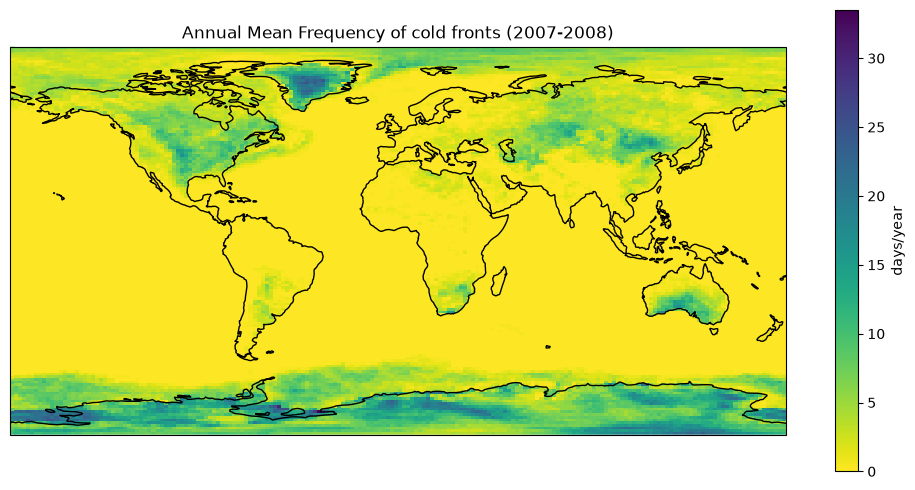

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()})
da_fronts.mean(dim="year").plot(
    ax=ax,
    cmap="viridis_r",
    cbar_kwargs={"label": "days/year"},
    transform=ccrs.PlateCarree(),
)
ax.coastlines()
ax.set_title("Annual Mean Frequency of cold fronts (2007-2008)")
plt.tight_layout()
plt.show()

---

## Learn more

If you want to see ways of applying this method to a different analysis check 

**Using Rapid Temperature Falls to Estimate Future Strong Cold Front Frequency in CMIP6 Climate Projections** by Paola B. Corrales, Martin Singh, Michael J. Reeder ([https://doi.org/10.1029/2026GL124031](https://doi.org/10.1029/2026GL124031))